# Neural-network HNBM: an end-to-end benchmark

This notebook trains the `hnbm` framework's `NNBoostClassifier` on a nonlinear binary-classification problem and compares it with XGBoost and LightGBM. The aim is a transparent, reproducible demonstration—not a claim that one model wins on every dataset.

`NNBoostClassifier` is a Newton boosting ensemble whose base-learner pool contains shallow neural networks. At every round HNBM computes gradient/Hessian information, fits a sampled network to the Newton target using Hessians as sample weights, and adds its prediction to the ensemble.

## Setup

Run this notebook from the repository root after installing HNBM and the two optional baselines:

```bash
python -m pip install -e . xgboost lightgbm pandas matplotlib
```

In [1]:
import sys
import time
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.metrics import (
    accuracy_score, ConfusionMatrixDisplay, log_loss, roc_auc_score, RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Some old LightGBM installations eagerly import an incompatible Dask.
# Disabling that optional integration is safe for this in-memory NumPy example.
try:
    from lightgbm import LGBMClassifier
except (AttributeError, ImportError):
    for module_name in list(sys.modules):
        if module_name == 'lightgbm' or module_name.startswith('lightgbm.'):
            del sys.modules[module_name]
    sys.modules['dask'] = None
    from lightgbm import LGBMClassifier

from hnbm import NNBoostClassifier

SEED = 42
np.random.seed(SEED)

## Example data

Two noisy interlocking moons provide a smooth nonlinear decision boundary. Eight independent nuisance features make the task less toy-like and test whether the models can ignore irrelevant inputs. We reserve separate train, validation, and test sets (64% / 16% / 20%). The test set is touched only once for the final table.

In [2]:
X_signal, y = make_moons(n_samples=2400, noise=0.24, random_state=SEED)
rng = np.random.default_rng(SEED)
X = np.column_stack([X_signal, rng.normal(size=(len(y), 8))])

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=SEED
)

# Neural learners benefit from scaling. Applying the same transformation to all
# models keeps their inputs identical (tree models are scale-insensitive).
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s = scaler.transform(X_test)

pd.Series({
    'train rows': len(y_train), 'validation rows': len(y_valid),
    'test rows': len(y_test), 'features': X.shape[1],
    'positive-class rate': y.mean(),
})

train rows             1536.0
validation rows         384.0
test rows               480.0
features                 10.0
positive-class rate       0.5
dtype: float64

## Define the models

Important neural HNBM controls:

- `hidden_layer_sizes=(8, 16, 32)` creates a heterogeneous pool of three one-hidden-layer networks.
- `learning_rate_nn` and `max_iter` train each base network; `learning_rate` shrinks its contribution to the ensemble.
- `line_search=True` chooses a per-round contribution weight.
- `eval_set` plus `early_stopping_rounds` monitors held-out logistic loss.
- `subsample=0.85` adds stochastic regularization.

The baseline settings are sensible small-data defaults rather than an exhaustive hyperparameter search. All models use the same split and seed.

In [3]:
models = {
    'Neural HNBM': NNBoostClassifier(
        num_iterations=35, learning_rate=0.12,
        hidden_layer_sizes=(8, 16, 32), activation='tanh',
        alpha=1e-3, learning_rate_nn=0.03, max_iter=120, tol=1e-5,
        selection_strategy='random', line_search=True,
        early_stopping_rounds=8, subsample=0.85,
        random_state=SEED, verbose=False,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85, eval_metric='logloss',
        random_state=SEED, n_jobs=1,
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, num_leaves=15, max_depth=5, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        random_state=SEED, n_jobs=1, verbosity=-1,
    ),
}
models

{'Neural HNBM': NNBoostClassifier(activation='tanh', alpha=0.001, early_stopping_rounds=8,
                   hidden_layer_sizes=(8, 16, 32), learning_rate=0.12,
                   learning_rate_nn=0.03, line_search=True, max_iter=120,
                   num_iterations=35, random_state=42, subsample=0.85),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.85, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.05, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, n_estimators=200, n_jobs=1

In [4]:
rows = []
test_probabilities = {}

for name, model in models.items():
    started = time.perf_counter()
    if name == 'Neural HNBM':
        model.fit(X_train_s, y_train, eval_set=(X_valid_s, y_valid))
    else:
        model.fit(X_train_s, y_train)
    fit_seconds = time.perf_counter() - started

    probability = model.predict_proba(X_test_s)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    test_probabilities[name] = probability
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, prediction),
        'ROC AUC': roc_auc_score(y_test, probability),
        'log loss': log_loss(y_test, probability),
        'fit seconds': fit_seconds,
    })

results = pd.DataFrame(rows).set_index('model').sort_values('ROC AUC', ascending=False)
results.style.format({
    'accuracy': '{:.3f}', 'ROC AUC': '{:.3f}',
    'log loss': '{:.3f}', 'fit seconds': '{:.3f}',
})

,accuracy,ROC AUC,log loss,fit seconds
model,,,,
XGBoost,0.954,0.987,0.141,0.245
LightGBM,0.950,0.985,0.152,0.115
Neural HNBM,0.867,0.935,0.324,6.872


The neural HNBM should substantially beat random guessing (ROC AUC 0.5 and log loss about 0.693) and recover the curved signal despite eight nuisance features. On this tabular sample, the highly optimized tree boosters are expected to be both faster and more accurate. That is a useful benchmark result: the neural HNBM is effective, but its comparative advantage should be tested on domains where smooth distributed representations are appropriate. Exact timings vary by hardware.

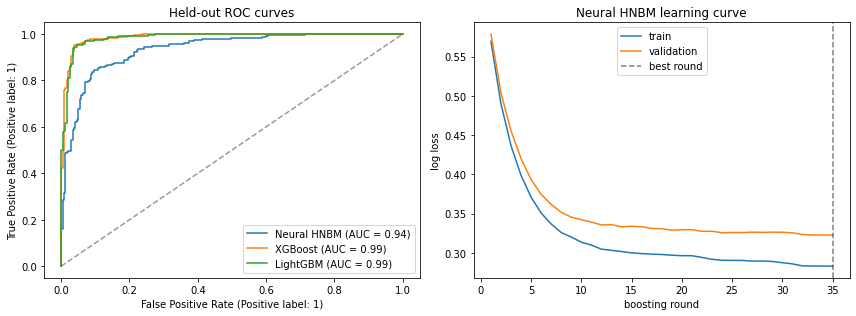

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, probability in test_probabilities.items():
    RocCurveDisplay.from_predictions(y_test, probability, name=name, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title('Held-out ROC curves')

history = models['Neural HNBM'].history_
rounds = np.arange(1, len(history['training_loss']) + 1)
axes[1].plot(rounds, history['training_loss'], label='train')
if history['validation_loss']:
    axes[1].plot(rounds, history['validation_loss'], label='validation')
axes[1].axvline(models['Neural HNBM'].best_iteration_ + 1, color='k', ls='--', alpha=0.5, label='best round')
axes[1].set(xlabel='boosting round', ylabel='log loss', title='Neural HNBM learning curve')
axes[1].legend()
plt.tight_layout()
plt.show()

## What to try next

For a new dataset, preserve a final untouched test set and tune only against validation or cross-validation. Useful HNBM searches include the ensemble shrinkage (`learning_rate`), the pool (`hidden_layer_sizes`), base-network optimization (`learning_rate_nn`, `max_iter`), and regularization (`alpha`, `subsample`). Use `selection_strategy='greedy'` when the extra cost of fitting every candidate at every round is acceptable. For regression, replace the estimator with `NNBoostRegressor` and evaluate RMSE/MAE/R².